# Computing Maximum Drawdown



/var/folders/7t/kmrnhcf94kd0l516vmmk1pd00000gn/T/ipykernel_49731/2548082398.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  me_m = pd.read_csv("data/Portfolios_Formed_on_ME_monthly_EW.csv",


<Axes: >

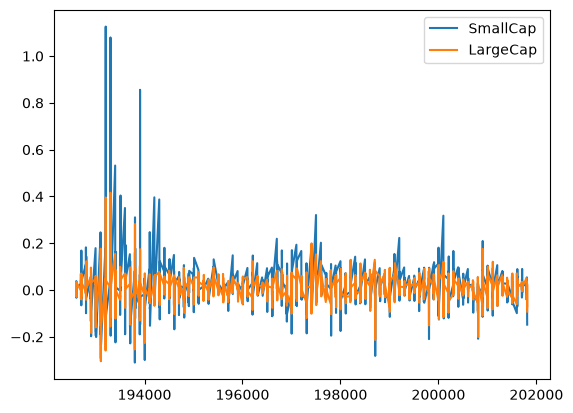

In [5]:
import pandas as pd

me_m = pd.read_csv("data/Portfolios_Formed_on_ME_monthly_EW.csv",
                   header=0, index_col=0, parse_dates=True, na_values=-99.99)
rets = me_m[['Lo 20', 'Hi 20']]
rets.columns = ['SmallCap', 'LargeCap']
rets = rets/100
rets.plot.line()

## Timeseries - forcing the index to be a datetime

We asked Pandas to `parse_dates` in `read_csv()`. Check if it was able to do so with the index:

In [6]:
rets.index

Index([192607, 192608, 192609, 192610, 192611, 192612, 192701, 192702, 192703,
       192704,
       ...
       201803, 201804, 201805, 201806, 201807, 201808, 201809, 201810, 201811,
       201812],
      dtype='int64', length=1110)

The `dtype` is `int64` which suggests that it was not automatically converted to a date time index. The simplest way to force it to be a timeseries is by reformatting the index data to a `datetime` type :

In [7]:
rets.index = pd.to_datetime(rets.index, format="%Y%m")
rets.index

DatetimeIndex(['1926-07-01', '1926-08-01', '1926-09-01', '1926-10-01',
               '1926-11-01', '1926-12-01', '1927-01-01', '1927-02-01',
               '1927-03-01', '1927-04-01',
               ...
               '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01',
               '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01',
               '2018-11-01', '2018-12-01'],
              dtype='datetime64[us]', length=1110, freq=None)

This looks good except that we know this is monthly data, and it's showing up with an index that is date stamped. We can fix this using the `to_period` method. We'll see several more examples of Pandas support for timeseries during the course.

In [9]:
rets.index = rets.index.to_period('M')
rets.head()

,SmallCap,LargeCap
1926-07,-0.0057,0.0333
1926-08,0.0384,0.0233
1926-09,-0.0048,-0.0009
1926-10,-0.0329,-0.0295
1926-11,-0.0055,0.0316


In [10]:
rets.info()

<class 'pandas.DataFrame'>
PeriodIndex: 1110 entries, 1926-07 to 2018-12
Freq: M
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SmallCap  1110 non-null   float64
 1   LargeCap  1110 non-null   float64
dtypes: float64(2)
memory usage: 26.0 KB


In [11]:
rets.describe()

,SmallCap,LargeCap
count,1110.000000,1110.000000
mean,0.015904,0.009434
std,0.097197,0.056325
min,-0.309900,-0.304000
25%,-0.026950,-0.019175
50%,0.011900,0.012300
75%,0.048300,0.038375
max,1.126000,0.416300


## Computing Drawdowns

1. Convert the time series of returns to a time series that represents a wealth index
2. Compute a time series of the previous peaks
3. Compute the Drawdown as the difference between the previous peak and the current value


<Axes: >

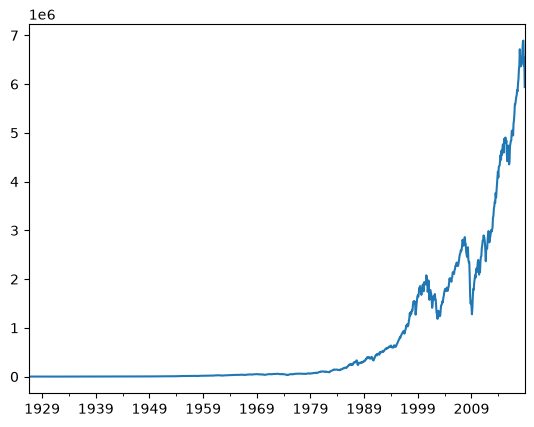

In [12]:
wealth_index = 1000*(1+rets["LargeCap"]).cumprod()
wealth_index.plot()

<Axes: >

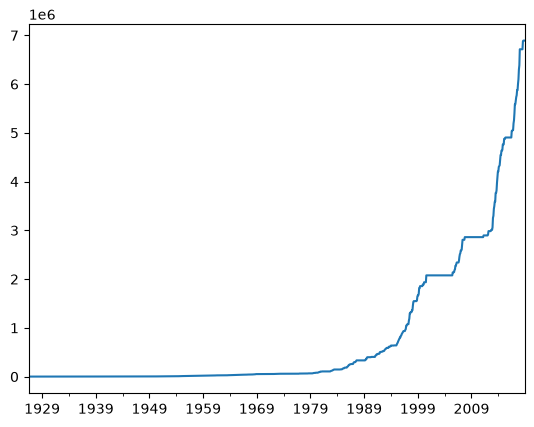

In [13]:
previous_peaks = wealth_index.cummax()
previous_peaks.plot()

<Axes: >

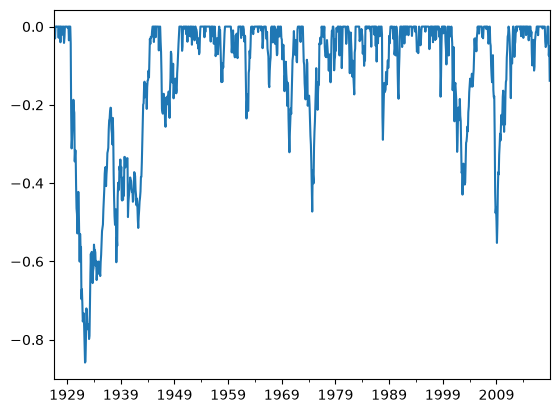

In [14]:
drawdown = (wealth_index - previous_peaks)/previous_peaks
drawdown.plot()

In [15]:
drawdown.min()

np.float64(-0.8585017065044246)

<Axes: >

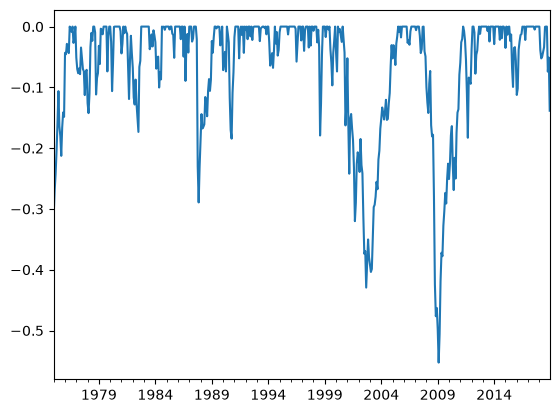

In [16]:
drawdown["1975":].plot()

In [17]:
drawdown["1975":].min()

np.float64(-0.5527349978713652)

In [18]:
drawdown["1975":].idxmin()

Period('2009-02', 'M')

# Drawdown Function

The function will take as input, a timeseries of returns, and return a timeseries as a DataFrame that contains the wealth index, the previous peaks and the drawdowns as a percent.

In [19]:
def drawdown(return_series: pd.Series):
    """Takes a time series of asset returns.
       returns a DataFrame with columns for
       the wealth index, 
       the previous peaks, and 
       the percentage drawdown
    """
    wealth_index = 1000*(1+return_series).cumprod()
    previous_peaks = wealth_index.cummax()
    drawdowns = (wealth_index - previous_peaks)/previous_peaks
    return pd.DataFrame({"Wealth": wealth_index, 
                         "Previous Peak": previous_peaks, 
                         "Drawdown": drawdowns})

drawdown(rets["LargeCap"]).head()

,Wealth,Previous Peak,Drawdown
1926-07,1033.300000,1033.300000,0.000000
1926-08,1057.375890,1057.375890,0.000000
1926-09,1056.424252,1057.375890,-0.000900
1926-10,1025.259736,1057.375890,-0.030373
1926-11,1057.657944,1057.657944,0.000000


<Axes: >

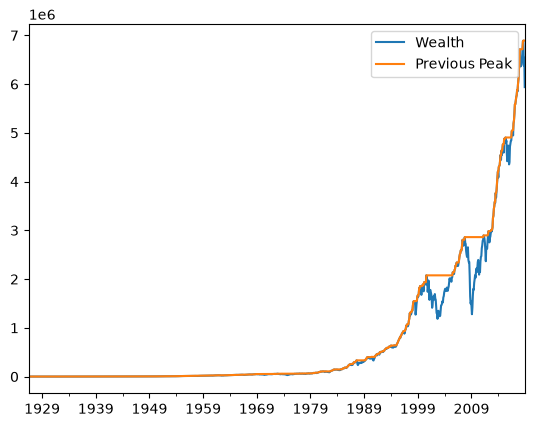

In [20]:
drawdown(rets["LargeCap"])[["Wealth","Previous Peak"]].plot()

<Axes: >

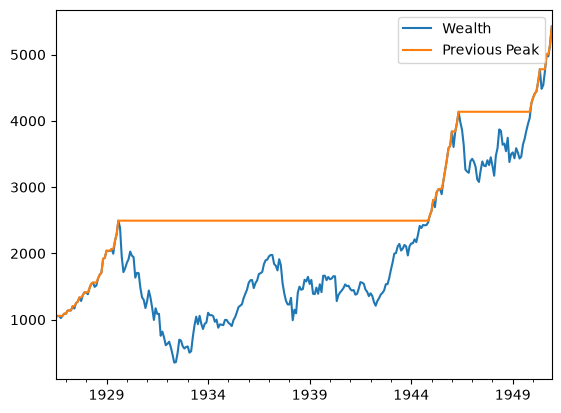

In [21]:
drawdown(rets[:"1950"]["LargeCap"])[["Wealth","Previous Peak"]].plot()

In [22]:
drawdown(rets["LargeCap"])["Drawdown"].min()

np.float64(-0.8585017065044246)

In [23]:
drawdown(rets["SmallCap"])["Drawdown"].min()

np.float64(-0.8672279770834406)

In [24]:
drawdown(rets["LargeCap"])["Drawdown"].idxmin()

Period('1932-05', 'M')

In [25]:
drawdown(rets["SmallCap"])["Drawdown"].idxmin()

Period('1932-05', 'M')

In [26]:
drawdown(rets["LargeCap"]["1975":])["Drawdown"].idxmin()

Period('2009-02', 'M')

In [27]:
drawdown(rets["SmallCap"]["1975":])["Drawdown"].idxmin()

Period('2009-02', 'M')

In [28]:
drawdown(rets["SmallCap"]["1975":])["Drawdown"].min()

np.float64(-0.6248092431236988)

In [29]:
drawdown(rets["LargeCap"]["1999":"2015"])["Drawdown"].min()

np.float64(-0.5527349978713653)

In [30]:
drawdown(rets["LargeCap"]["1999":"2015"])["Drawdown"].idxmin()

Period('2009-02', 'M')